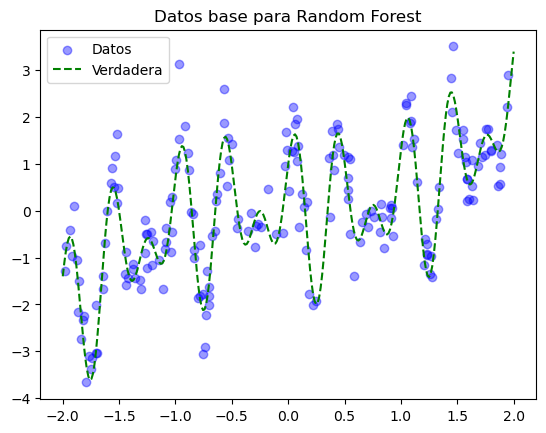

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample

np.random.seed(42)

def predict_tree(tree, x):
    """
    Predicción recursiva para un solo árbol.
    Tecnología inversa: si es hoja (float), devuelve la media; si es nodo, elige rama izquierda o derecha según el split.
    """
    if not isinstance(tree, dict):
        return tree  # hoja: valor constante (media de y en la región)
    
    if x < tree['split']:
        return predict_tree(tree['left'], x)
    else:
        return predict_tree(tree['right'], x)

# Funcion verdadera compleja (para ver reduccion de varianza)
def true_function(x):
    return np.sin(6 * np.pi * x) + np.cos(4 * np.pi * x ) + 0.3 * x**3

N = 200
x = np.sort(np.random.uniform(-2, 2, N))
y = true_function(x) + np.random.normal(0, 0.5, N)

x_test = np.linspace(-2, 2, 300)
y_true = true_function(x_test)

# Grafico base
plt.scatter(x, y, color='blue', alpha=0.4, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.title('Datos base para Random Forest')
plt.legend()
plt.show()

In [36]:
def regression_tree_fit(x, y, max_depth=10, min_samples_split=5, m_features=None):
    """
    Árbol de regresión con soporte para 1D o 2D en x.
    """
    # Asegurar x como 2D (N, n_features)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    
    n_samples, n_features = x.shape
    
    def find_best_split(x, y):
        best_split = None
        best_rss = np.inf
        
        # Selección aleatoria de features
        if m_features is None:
            features = range(n_features)
        else:
            features = np.random.choice(n_features, m_features, replace=False)
        
        for feat in features:
            splits = np.unique(x[:, feat])
            for split in splits:
                left = x[:, feat] < split
                right = ~left
                if np.sum(left) < min_samples_split or np.sum(right) < min_samples_split:
                    continue
                rss_left = np.sum((y[left] - np.mean(y[left]))**2)
                rss_right = np.sum((y[right] - np.mean(y[right]))**2)
                rss_total = rss_left + rss_right
                if rss_total < best_rss:
                    best_rss = rss_total
                    best_split = (feat, split)
        return best_split

    def build_tree(x, y, depth=0):
        if depth >= max_depth or len(y) < min_samples_split:
            return np.mean(y)
        
        split_info = find_best_split(x, y)
        if split_info is None:
            return np.mean(y)
        
        feat, split_val = split_info
        left = x[:, feat] < split_val
        right = ~left
        
        return {
            'feat': feat,
            'split': split_val,
            'left': build_tree(x[left], y[left], depth + 1),
            'right': build_tree(x[right], y[right], depth + 1)
        }
    
    return build_tree(x, y)

In [37]:
def random_forest(x, y, B=50, max_depth=10, m_features='sqrt'):
    """
    Random Forest: bagging + selección aleatoria de features en cada split.
    Tecnología inversa: decorrelaciona árboles → reduce varianza más que bagging solo.
    m_features: 'sqrt' (típico), 'log2' o número fijo.
    """
    n_features = x.shape[1] if x.ndim > 1 else 1
    if m_features == 'sqrt':
        m = int(np.sqrt(n_features))
    elif m_features == 'log2':
        m = int(np.log2(n_features))
    else:
        m = m_features
    
    forest = []
    for b in range(B):
        x_boot, y_boot = resample(x, y, replace=True)
        tree = regression_tree_fit(x_boot, y_boot, max_depth=max_depth, m_features=m)
        forest.append(tree)
    return forest

def predict_forest(forest, x_new):
    """
    Predicción de Random Forest: promedio de las predicciones de todos los árboles.
    Tecnología inversa: cada árbol da una constante en su región → promedio suaviza y reduce varianza.
    """
    predictions = []
    for tree in forest:
        # Llamar a predict_tree (la función para un solo árbol), NO a predict_forest
        pred = predict_tree(tree, x_new)
        predictions.append(pred)
    
    return np.mean(predictions)

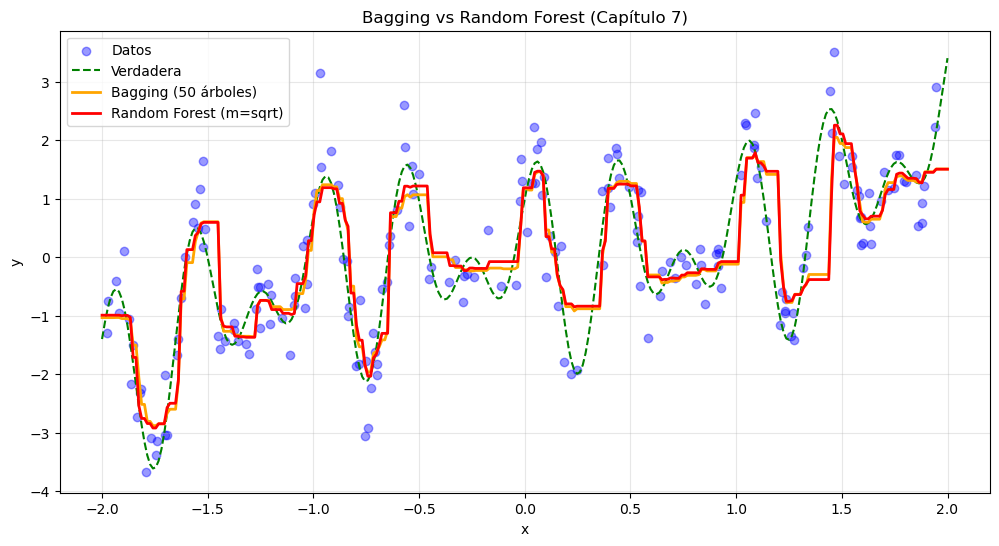

In [38]:
# Convertir x 1D a 2D explícitamente (N, 1)
X_2d = x.reshape(-1, 1)  # o x[:, np.newaxis] si ya es 1D
forest_bag = random_forest(X_2d, y, B=50, max_depth=10, m_features=None)

# Random Forest (m_features='sqrt')
forest_rf = random_forest(x[:, np.newaxis], y, B=50, max_depth=10, m_features='sqrt')

# Predicciones
y_bag = np.array([predict_forest(forest_bag, xi) for xi in x_test])
y_rf = np.array([predict_forest(forest_rf, xi) for xi in x_test])

plt.figure(figsize=(12, 6))
plt.scatter(x, y, color='blue', alpha=0.4, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.plot(x_test, y_bag, 'orange', linewidth=2, label='Bagging (50 árboles)')
plt.plot(x_test, y_rf, 'r-', linewidth=2, label='Random Forest (m=sqrt)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Bagging vs Random Forest (Capítulo 7)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusiones del Capítulo 7  
(Additive Models, Trees, and Related Methods)

- *Regression Trees desde cero*:  
  - Árboles dividen el espacio en regiones constantes (escalones) que minimizan RSS local.  
  - Profundidad baja → modelo simple, bajo overfitting.  
  - Profundidad alta → overfitting (escalones pequeños siguen ruido).

- *Bagging (Bootstrap Aggregating)*:  
  - Entrena múltiples árboles profundos en muestras bootstrap.  
  - Promedio de predicciones → reduce varianza (curva naranja más suave que un solo árbol).  
  - No reduce bias (árboles profundos mantienen bajo bias).

- *Random Forest*:  
  - Bagging + selección aleatoria de features en cada split (m ≈ √p).  
  - Decorrelaciona árboles → reducción de varianza aún mayor que bagging puro.  
  - Resultado: curva roja más estable y cercana a la verdadera (mejor generalización).

- *Lecciones clave (tecnología inversa)*:  
  - Árboles solos: alta varianza → sobreajuste fácil.  
  - Bagging: promedia → suaviza.  
  - Random Forest: aleatoriedad extra → mejor que bagging solo.  
  - Todo depende del tradeoff bias-variance: profundidad y número de árboles controlan complejidad.

Este capítulo muestra cómo ensembles (bagging + RF) convierten modelos débiles (árboles) en potentes, tal como explica ESL.